## Workspace setup

In [1]:
from datetime import datetime  
import uproot
from functools import partial
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys, os

user = os.getenv("USER")
if user == None:
    sys.path.append("/home/jovyan/TPCReco/PythonAnalysis/python/")
    os.chdir("/home/jovyan/TPCReco/PythonAnalysis/")
else:
    sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")
    os.chdir('/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/ipynb/')

import io_functions as io
import utility_functions as utils
import importlib
# os.makedirs("fig_png", exist_ok=True)

2026-06-01 19:17:32.866434: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 19:17:33.312198: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-01 19:17:34.739562: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Training dataset preparation

In [28]:
import tensorflow as tf
import numpy as np

tf.keras.backend.clear_session()

batchSize = 8

raw_dataset = tf.data.Dataset.load(
    "MergedEvent_Track3D_TwoProng_gun_MC_50k",
    compression="GZIP"
)

dataset = raw_dataset.map(
    lambda event: (
        event["sim"][0],
        event["sim"][1]
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.map(
    lambda x, y: (
        tf.reshape(x, io.projections.shape),
        tf.reshape(y, (9,))
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

nEvents = tf.data.experimental.cardinality(dataset).numpy()
print("number of events:", nEvents)

shuffle_buffer = 1024

dataset = dataset.shuffle(
    buffer_size=shuffle_buffer,
    seed=42,
    reshuffle_each_iteration=False
)

val_fraction = 0.2
nVal = int(nEvents * val_fraction)
nTrain = nEvents - nVal

val_dataset_raw = dataset.take(nVal)
train_dataset_raw = dataset.skip(nVal)

print("train events:", nTrain)
print("validation events:", nVal)

y_train = np.array([y.numpy() for _, y in train_dataset_raw])

y_mean = y_train.mean(axis=0).astype(np.float32)
y_std = y_train.std(axis=0).astype(np.float32)
y_std[y_std == 0] = 1.0

for name, mean, std in zip(utils.columnsXYZ, y_mean, y_std):
    print(f"{name:8s} mean = {mean:8.3f}, std = {std:8.3f}")

y_mean_tf = tf.constant(y_mean, dtype=tf.float32)
y_std_tf = tf.constant(y_std, dtype=tf.float32)

def normalize_y(x, y):
    return x, (y - y_mean_tf) / y_std_tf

def denormalize_y(y_norm):
    return y_norm * y_std + y_mean

train_dataset = (
    train_dataset_raw
    .map(normalize_y, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batchSize, drop_remainder=True)
    .prefetch(1)
)

validation_dataset = (
    val_dataset_raw
    .map(normalize_y, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batchSize, drop_remainder=True)
    .prefetch(1)
)

#moze lepiej uzyc prefetch(1)

x_batch, y_batch = next(iter(train_dataset))

print("x shape:", x_batch.shape)
print("y shape:", y_batch.shape)
print("single batch y mean:", tf.reduce_mean(y_batch, axis=0).numpy())
print("single batch y std:", tf.math.reduce_std(y_batch, axis=0).numpy())

number of events: 44261
train events: 35409
validation events: 8852
xVtx     mean =    0.826, std =   56.797
xAlpha   mean =   -0.242, std =   63.773
xCarbon  mean =    0.182, std =   57.693
yVtx     mean =   -0.002, std =    1.005
yAlpha   mean =    0.225, std =   32.655
yCarbon  mean =   -0.044, std =    5.620
zVtx     mean =  -36.097, std =   22.781
zAlpha   mean =  -36.577, std =   28.089
zCarbon  mean =  -36.036, std =   27.505
x shape: (8, 256, 512, 3)
y shape: (8, 9)
single batch y mean: [ 0.42404205  0.55074024  0.39864504  0.27863103 -0.28675497  0.14411606
 -0.19950573  0.01955679 -0.18410367]
single batch y std: [0.5528441  0.50919116 0.5605694  0.60816765 1.1524134  1.0917087
 0.6819967  1.3795431  0.69287264]


## Model definition

In [3]:
def getModel_xyz_old():

    model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(256,512,3), name="input_image", dtype=tf.float32),
      tf.keras.layers.Conv2D(filters = 16*3, kernel_size = (16,32), groups=3,
                             padding='same', activation='relu', 
                             data_format="channels_last"),
      tf.keras.layers.MaxPooling2D(pool_size=(16, 32)),
      tf.keras.layers.Conv2D(filters=16*3, kernel_size=(8,16), groups=3,
                              padding='same', activation='relu', 
                              data_format="channels_last"),
      tf.keras.layers.MaxPooling2D(),
      tf.keras.layers.Conv2D(filters=8*3, kernel_size=2, groups=3, 
                             padding='same', activation='relu', 
                              data_format="channels_last"),
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(9, activation="linear")
      ])

    initial_learning_rate = 0.01
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                      decay_steps=1990,
                      decay_rate=0.98,
                      staircase=False)
    
    model.summary()
    return model
##########################################################


y_mean_tf = tf.constant(y_mean, dtype=tf.float32)
y_std_tf = tf.constant(y_std, dtype=tf.float32)

def xyz_physics_loss(y_true_norm, y_pred_norm):
    """
    Loss dla modelu przewidującego 9 współrzędnych:
    [xVtx, xAlpha, xCarbon,
     yVtx, yAlpha, yCarbon,
     zVtx, zAlpha, zCarbon]

    y_true_norm i y_pred_norm są w skali znormalizowanej.
    """
    
    coord_loss = tf.reduce_mean(tf.square(y_true_norm - y_pred_norm))

    y_true = y_true_norm * y_std_tf + y_mean_tf
    y_pred = y_pred_norm * y_std_tf + y_mean_tf

    xVtx_t, xAlpha_t, xCarbon_t = y_true[:, 0], y_true[:, 1], y_true[:, 2]
    yVtx_t, yAlpha_t, yCarbon_t = y_true[:, 3], y_true[:, 4], y_true[:, 5]
    zVtx_t, zAlpha_t, zCarbon_t = y_true[:, 6], y_true[:, 7], y_true[:, 8]

    xVtx_p, xAlpha_p, xCarbon_p = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
    yVtx_p, yAlpha_p, yCarbon_p = y_pred[:, 3], y_pred[:, 4], y_pred[:, 5]
    zVtx_p, zAlpha_p, zCarbon_p = y_pred[:, 6], y_pred[:, 7], y_pred[:, 8]

    v_alpha_t = tf.stack([
        xAlpha_t - xVtx_t,
        yAlpha_t - yVtx_t,
        zAlpha_t - zVtx_t
    ], axis=1)

    v_alpha_p = tf.stack([
        xAlpha_p - xVtx_p,
        yAlpha_p - yVtx_p,
        zAlpha_p - zVtx_p
    ], axis=1)

    v_carbon_t = tf.stack([
        xCarbon_t - xVtx_t,
        yCarbon_t - yVtx_t,
        zCarbon_t - zVtx_t
    ], axis=1)

    v_carbon_p = tf.stack([
        xCarbon_p - xVtx_p,
        yCarbon_p - yVtx_p,
        zCarbon_p - zVtx_p
    ], axis=1)

    d_alpha_t = tf.sqrt(tf.reduce_sum(tf.square(v_alpha_t), axis=1) + 1e-6)
    d_alpha_p = tf.sqrt(tf.reduce_sum(tf.square(v_alpha_p), axis=1) + 1e-6)

    d_carbon_t = tf.sqrt(tf.reduce_sum(tf.square(v_carbon_t), axis=1) + 1e-6)
    d_carbon_p = tf.sqrt(tf.reduce_sum(tf.square(v_carbon_p), axis=1) + 1e-6)

    alpha_length_loss = tf.reduce_mean(tf.square((d_alpha_p - d_alpha_t) / 50.0))
    carbon_length_loss = tf.reduce_mean(tf.square((d_carbon_p - d_carbon_t) / 10.0))
    
    v_alpha_t_unit = tf.math.l2_normalize(v_alpha_t, axis=1)
    v_alpha_p_unit = tf.math.l2_normalize(v_alpha_p, axis=1)

    cos_alpha = tf.reduce_sum(v_alpha_t_unit * v_alpha_p_unit, axis=1)
    cos_alpha = tf.clip_by_value(cos_alpha, -1.0, 1.0)

    alpha_direction_loss = tf.reduce_mean(1.0 - cos_alpha)

    total_loss = (
        coord_loss
        + 0.5 * alpha_length_loss
        + 0.5 * carbon_length_loss
        + 0.2 * alpha_direction_loss
    )

    return total_loss

def projection_branch_light(input_layer, name_prefix):

    x = tf.keras.layers.Conv2D(
        8, kernel_size=(5, 5), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name_prefix}_conv1"
    )(input_layer)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool1")(x)

    x = tf.keras.layers.Conv2D(
        16, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name_prefix}_conv2"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool2")(x)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name=f"{name_prefix}_conv3"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"{name_prefix}_pool3")(x)

    return x

def getModel_xyz_branches_light():

    inputs = tf.keras.layers.Input(
        shape=(256, 512, 3),
        name="input_image",
        dtype=tf.float32
    )

    u = tf.keras.layers.Lambda(lambda x: x[:, :, :, 0:1], name="U_projection")(inputs)
    v = tf.keras.layers.Lambda(lambda x: x[:, :, :, 1:2], name="V_projection")(inputs)
    w = tf.keras.layers.Lambda(lambda x: x[:, :, :, 2:3], name="W_projection")(inputs)

    u_features = projection_branch_light(u, "U")
    v_features = projection_branch_light(v, "V")
    w_features = projection_branch_light(w, "W")

    x = tf.keras.layers.Concatenate(name="UVW_concatenate")(
        [u_features, v_features, w_features]
    )

    x = tf.keras.layers.Conv2D(
        64, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="fusion_conv1"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="fusion_pool1")(x)

    x = tf.keras.layers.Conv2D(
        64, kernel_size=(3, 3), padding="same",
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(),
        name="fusion_conv2"
    )(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="fusion_pool2")(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128, activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(
        64, activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(x)

    outputs = tf.keras.layers.Dense(9, activation="linear", name="xyz_output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.summary()
    return model

NameError: name 'y_mean' is not defined

## Model training

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_projection        │ (None, 256, 512,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_projection        │ (None, 256, 512,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_projection        │ (None, 256, 512,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_conv1 (Conv2D)    │ (None, 256, 512,  │        208 │ U_projection[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_conv1 (Conv2D)    │ (None, 256, 512,  │        208 │ V_projection[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_conv1 (Conv2D)    │ (None, 256, 512,  │        208 │ W_projection[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_pool1             │ (None, 128, 256,  │          0 │ U_conv1[0][0]     │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_pool1             │ (None, 128, 256,  │          0 │ V_conv1[0][0]     │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pool1             │ (None, 128, 256,  │          0 │ W_conv1[0][0]     │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_conv2 (Conv2D)    │ (None, 128, 256,  │      1,168 │ U_pool1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_conv2 (Conv2D)    │ (None, 128, 256,  │      1,168 │ V_pool1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_conv2 (Conv2D)    │ (None, 128, 256,  │      1,168 │ W_pool1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_pool2             │ (None, 64, 128,   │          0 │ U_conv2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ V_pool2             │ (None, 64, 128,   │          0 │ V_conv2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pool2             │ (None, 64, 128,   │          0 │ W_conv2[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ U_conv3 (Conv2D)    │ (None, 64, 128,   │      4,640 │ U_pool2[0][0]   

 Total params: 1,167,881 (4.46 MB)

 Trainable params: 1,167,881 (4.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80


2026-05-19 10:10:03.996412: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f741c002710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-19 10:10:03.996443: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-05-19 10:10:03.996449: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
2026-05-19 10:10:04.043166: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  28/4426 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 30.7099 - mae: 0.7876 - mse: 1.0357

I0000 00:00:1779185406.858303     609 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4423/4426 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 5.8266 - mae: 0.5861 - mse: 0.6127
Epoch 1: val_loss improved from None to 0.71854, saving model to ./training/best_xyz_physics_loss.keras
4426/4426 ━━━━━━━━━━━━━━━━━━━━ 194s 35ms/step - loss: 2.7461 - mae: 0.4960 - mse: 0.4568 - val_loss: 0.7185 - val_mae: 0.3765 - val_mse: 0.2827 - learning_rate: 3.0000e-04
Epoch 2/80
4422/4426 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9096 - mae: 0.3917 - mse: 0.3023
Epoch 2: val_loss did not improve from 0.71854
4426/4426 ━━━━━━━━━━━━━━━━━━━━ 193s 36ms/step - loss: 0.8129 - mae: 0.3781 - mse: 0.2854 - val_loss: 0.7460 - val_mae: 0.3248 - val_mse: 0.2195 - learning_rate: 3.0000e-04
Epoch 3/80
4426/4426 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6392 - mae: 0.3443 - mse: 0.2441
Epoch 3: val_loss improved from 0.71854 to 0.34731, saving model to ./training/best_xyz_physics_loss.keras
4426/4426 ━━━━━━━━━━━━━━━━━━━━ 195s 36ms/step - loss: 0.5953 - mae: 0.3352 - mse: 0.2349 - val_loss: 0.3473 - val_m

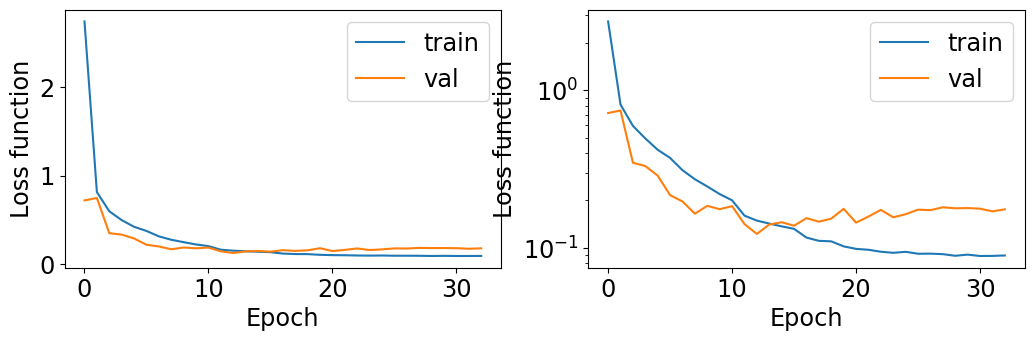

In [31]:
%%time
import plotting_functions as plf
importlib.reload(plf)

model = getModel_xyz_branches_light()

Nepochs = 80

optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)

model.compile(
    optimizer=optimizer,
    loss=xyz_physics_loss,
    metrics=["mse", "mae"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "./training/best_xyz_physics_loss.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=Nepochs,
    verbose=1,
    callbacks=callbacks
)

plf.plotTrainHistory(history)

In [24]:
# current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
# print("Training start. Current Time =", current_time)

# job_dir = f"training/{Nepochs:04d}_"+current_time+".keras"
# model.save(job_dir)

## Model performance on training data.

Fill Pandas DataFrame with true and response values.

In [42]:
%%time
import utility_functions as utils
importlib.reload(utils)
import pandas as pd
import numpy as np
import tensorflow as tf

tf.keras.backend.clear_session()
model_path = './training/0100_2026_May_17_19_02_58.keras'
model = tf.keras.models.load_model(
    model_path,
    safe_mode=False,
    custom_objects={
        "xyz_physics_loss": xyz_physics_loss
    }
)

rows = []

for features, labels_norm in validation_dataset:
    model_answer_norm = model(features, training=False).numpy()
    labels_norm = labels_norm.numpy()
    
    labels = denormalize_y(labels_norm)
    model_answer = denormalize_y(model_answer_norm)
    
    batch_data = np.column_stack((labels, model_answer))
    rows.append(batch_data)

data = np.vstack(rows)

df_XYZ = pd.DataFrame(
    data=data,
    columns=utils.getSimRecoColumns(utils.columnsXYZ)
)

df_XYZ.describe()

CPU times: user 54.4 s, sys: 378 ms, total: 54.8 s
Wall time: 36.4 s


,xVtx_sim,xAlpha_sim,xCarbon_sim,yVtx_sim,yAlpha_sim,yCarbon_sim,zVtx_sim,zAlpha_sim,zCarbon_sim,xVtx_reco,xAlpha_reco,xCarbon_reco,yVtx_reco,yAlpha_reco,yCarbon_reco,zVtx_reco,zAlpha_reco,zCarbon_reco
count,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000,8848.000000
mean,0.630767,-0.502785,-0.001264,-0.008783,-0.147489,0.002134,-35.761459,-36.216778,-35.703541,1.997584,-1.379229,-3.471038,0.069340,-0.365131,0.177672,-35.122955,-37.330788,-35.430199
std,57.406307,64.677460,58.229511,0.994400,33.031467,5.651392,22.975502,28.495592,27.737869,57.173046,62.284332,57.216805,0.930168,28.227470,4.952790,22.669014,27.423859,27.380215
min,-99.989540,-139.864563,-114.022804,-3.799604,-89.919418,-14.738889,-52.945583,-66.150398,-52.946159,-110.471718,-141.032959,-118.908524,-3.135555,-81.373108,-12.093597,-53.887482,-68.169357,-59.802528
25%,-49.357013,-51.652103,-49.835361,-0.667650,-18.611632,-4.325338,-49.496417,-52.934559,-52.946159,-48.311923,-52.901736,-53.847878,-0.571557,-16.627841,-3.714625,-48.711846,-53.555438,-52.240131
50%,0.953422,-1.262917,0.501452,-0.020292,-0.298895,-0.037228,-45.249107,-52.210663,-52.226849,2.048403,-1.558003,-3.549406,0.061555,-0.269751,0.114911,-44.867029,-51.414789,-50.236475
75%,50.280045,50.668119,50.258960,0.660229,18.499487,4.346972,-33.247221,-29.646145,-28.540929,52.396958,49.719916,46.892546,0.710331,15.912360,4.010822,-32.475641,-30.982953,-28.645043
max,99.998215,139.840469,113.220901,4.076410,89.970024,14.492574,47.555721,66.058975,62.964664,111.838669,135.970367,104.791039,3.271594,78.465324,13.857126,52.843937,71.294220,67.361206


In [14]:
# %%time
# import utility_functions as utils
# importlib.reload(utils)
# import pandas as pd
# model_path = "./training/0100_2026_May_17_17_27_17.keras" # val_mse: 12.0836, 50k, early_stopping: 27

# #model_path = "./training/0010_2026_Mar_27_15_08_49.keras" #  val_mse: 3.0631
# #model_path = "./training/0100_2026_Mar_27_17_45_38.keras" #  val_mse: 1.5725
# model = tf.keras.models.load_model(model_path)
# data = np.zeros_like(utils.getSimRecoColumns(utils.columnsXYZ).reshape(1,-1), dtype=float) 

# for aBatch in dataset.take(500):
#     features = aBatch[0]
#     labels = aBatch[1].numpy()
#     modelAnswer = model(features).numpy()
#     data = np.append(data, np.column_stack((labels,modelAnswer)), axis=0)

# df_XYZ = pd.DataFrame(data=data[1:], columns = utils.getSimRecoColumns(utils.columnsXYZ))
# df_XYZ.describe()  

CPU times: user 2min 30s, sys: 27.5 s, total: 2min 57s
Wall time: 1min 53s


,xVtx_sim,xAlpha_sim,xCarbon_sim,yVtx_sim,yAlpha_sim,yCarbon_sim,zVtx_sim,zAlpha_sim,zCarbon_sim,xVtx_reco,xAlpha_reco,xCarbon_reco,yVtx_reco,yAlpha_reco,yCarbon_reco,zVtx_reco,zAlpha_reco,zCarbon_reco
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.322112,-0.950784,-0.283886,-0.012455,-0.225565,0.019970,-35.691250,-36.313494,-35.611222,-0.744022,-0.665604,-1.770119,-0.031370,-1.439591,-0.074535,-34.872463,-36.317075,-34.734355
std,57.407473,64.648595,58.241073,0.993353,33.090762,5.647807,23.096982,28.435152,27.871203,57.857824,64.729857,58.636878,0.483106,33.028268,5.303528,23.270913,28.334161,28.104804
min,-99.989540,-139.864563,-114.022804,-3.799604,-89.919418,-14.738889,-52.945583,-66.150398,-52.946159,-107.343208,-150.764450,-119.728424,-4.335231,-102.034622,-17.480700,-56.209751,-65.337723,-65.843529
25%,-49.700338,-52.064154,-50.051031,-0.666929,-18.643254,-4.302907,-49.497767,-52.934366,-52.946159,-51.304585,-52.238653,-52.066170,-0.302784,-20.205409,-3.151229,-49.089580,-52.332331,-51.564440
50%,0.580938,-2.009143,0.025264,-0.019495,-0.426193,0.019949,-45.261631,-52.206566,-52.265232,-0.578069,-1.344466,-1.170656,-0.021356,-1.707152,-0.159146,-45.075851,-50.345903,-49.284819
75%,49.934445,49.821545,49.967244,0.659135,18.272003,4.346972,-33.143672,-29.780362,-28.466293,49.623928,51.173050,48.817904,0.271625,17.121641,2.886841,-31.628588,-30.275789,-28.222681
max,99.998215,139.840469,113.220901,4.076410,89.970024,14.271210,47.381966,66.130165,62.964664,109.997643,154.195496,116.122185,2.418103,101.922623,17.953407,54.678791,82.448639,70.163185


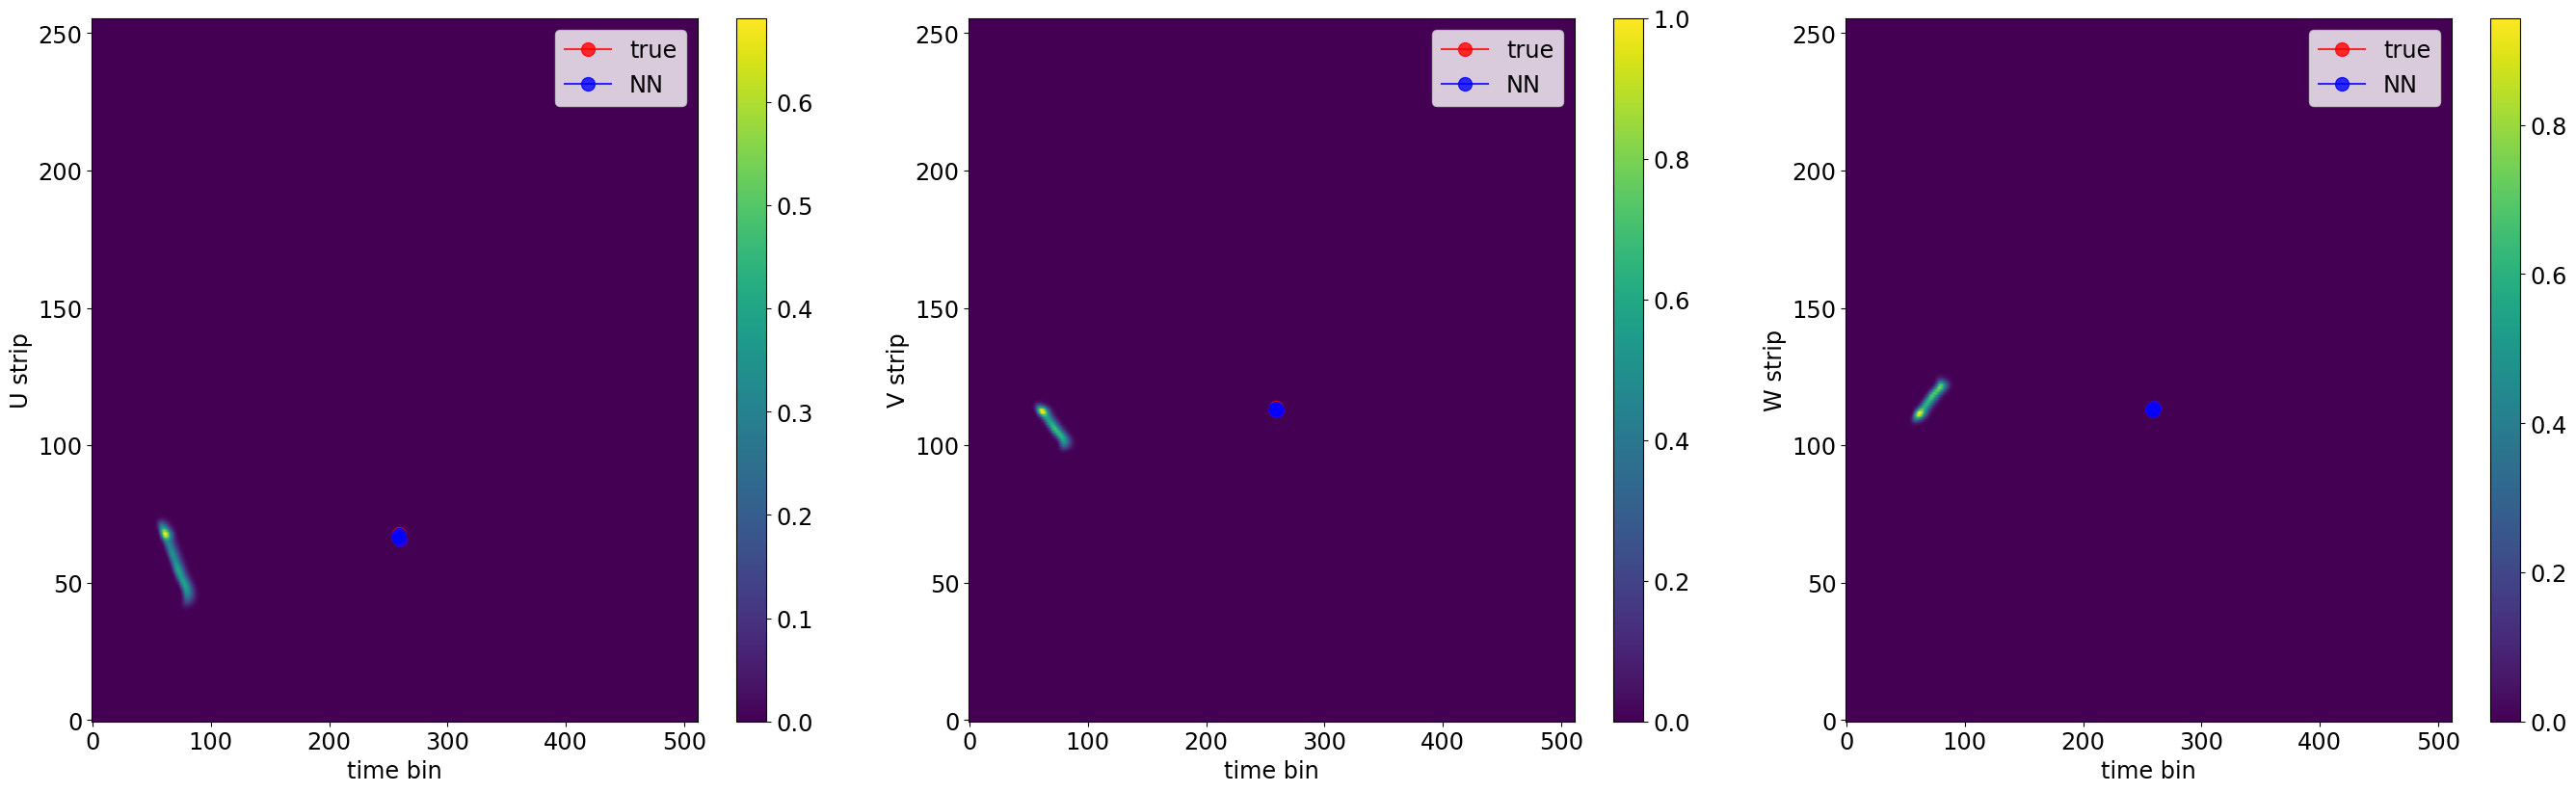

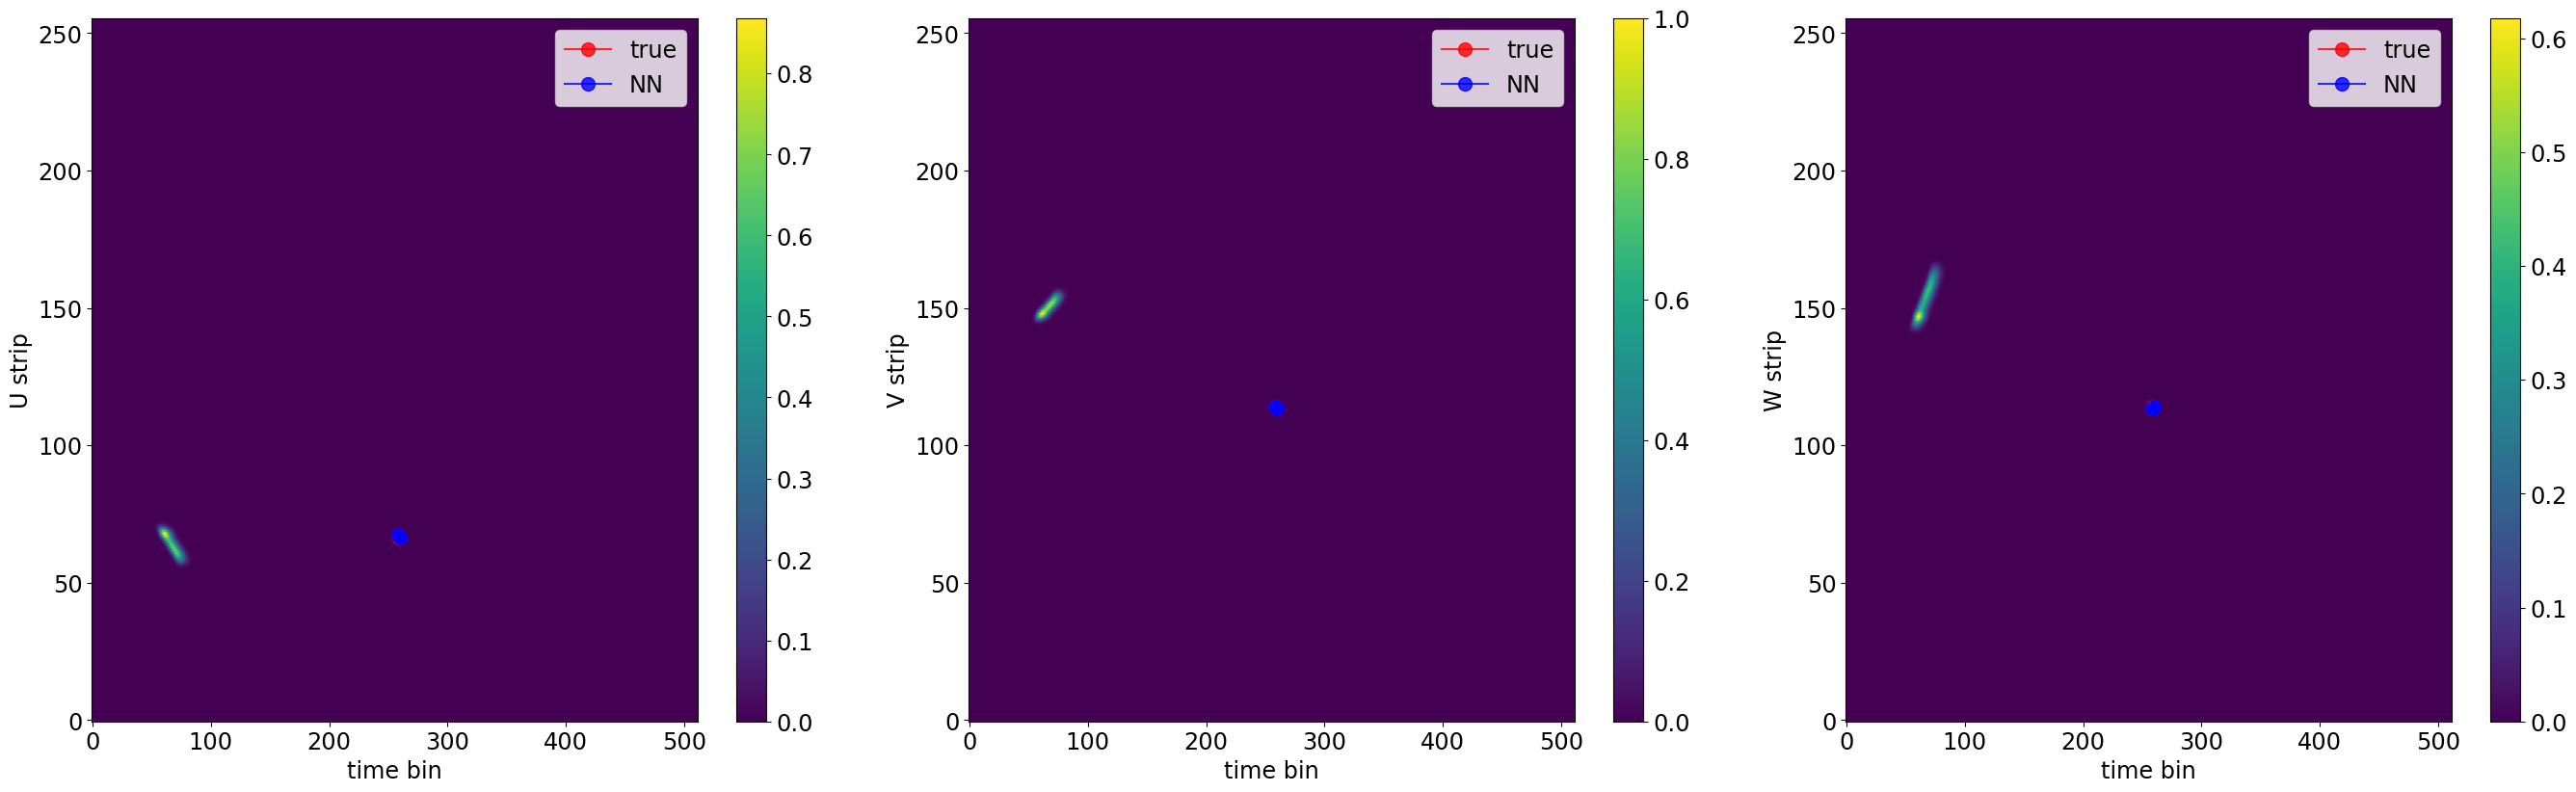

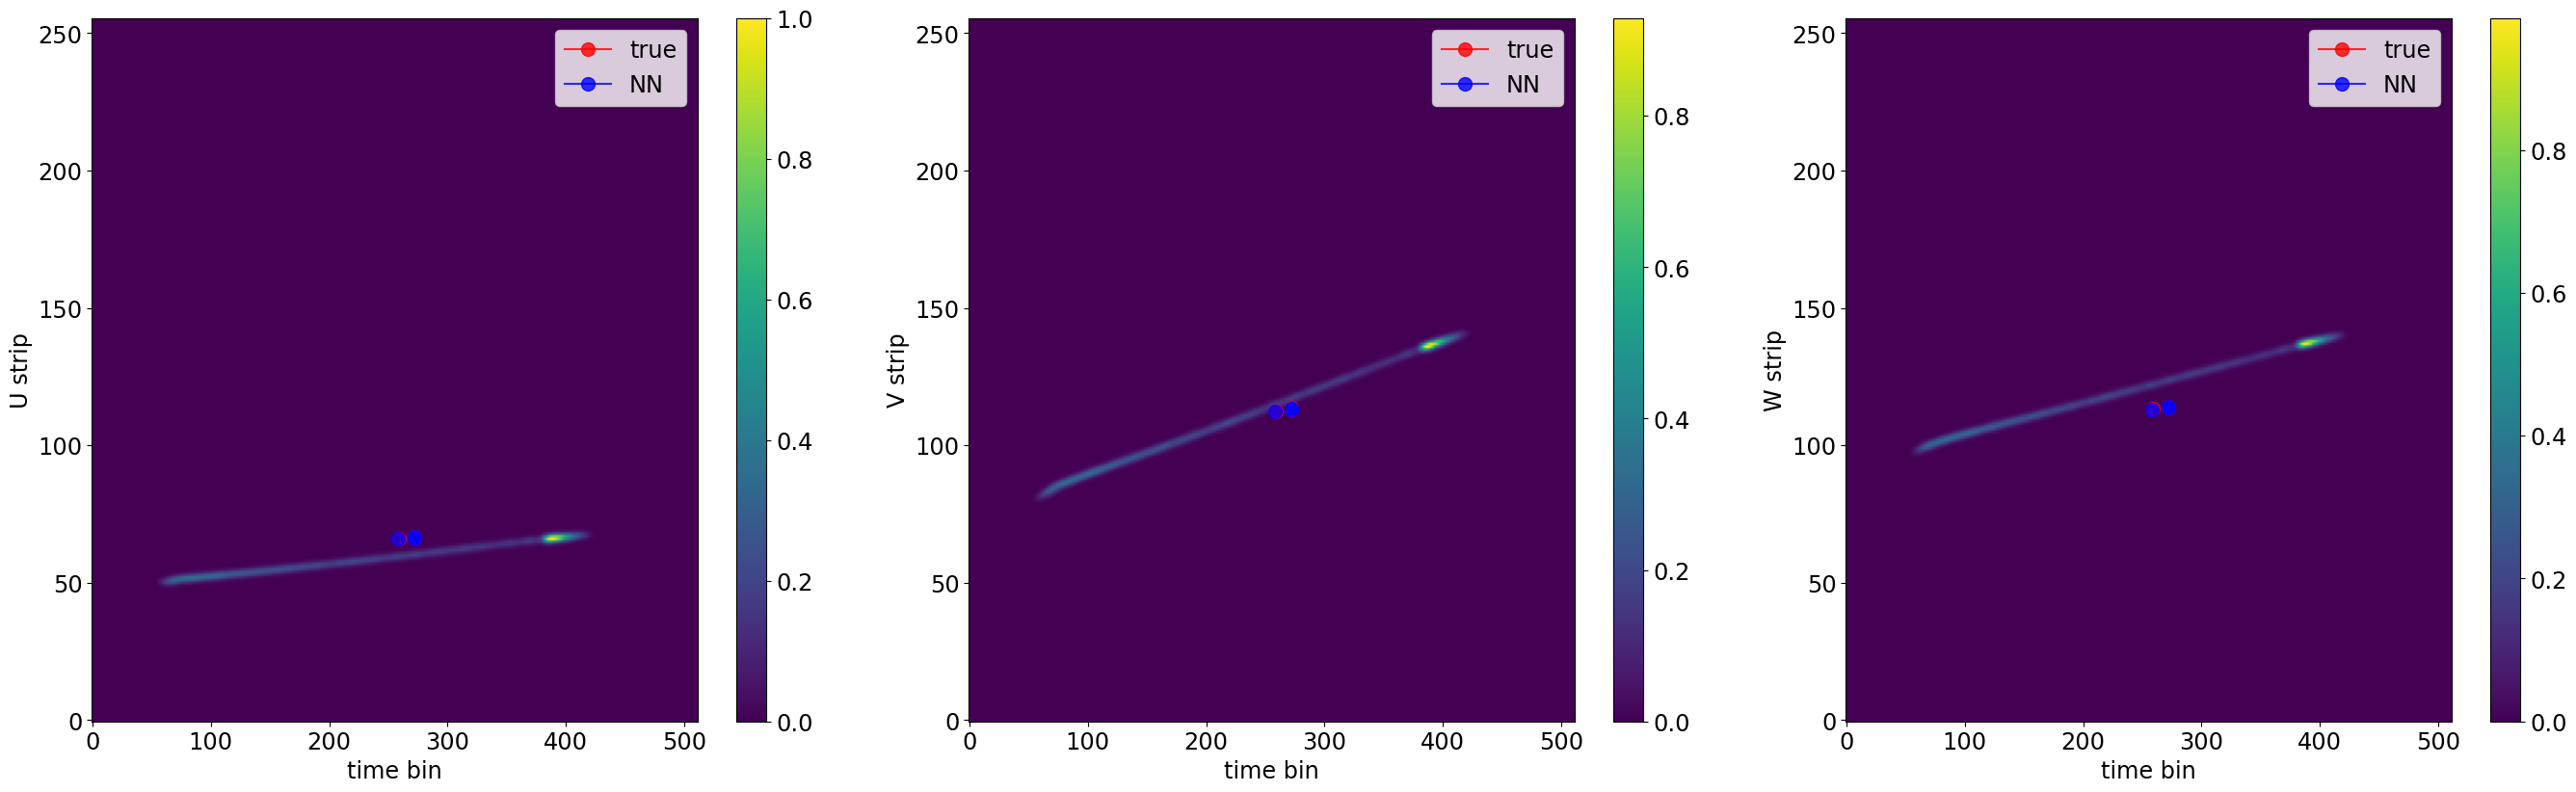

In [25]:
import plotting_functions as plf
importlib.reload(plf)

import utility_functions as utils
importlib.reload(utils)

for aBatch in validation_dataset.skip(100).take(3):
    plf.plotEvent(aBatch, model=model)

### Resolution plots

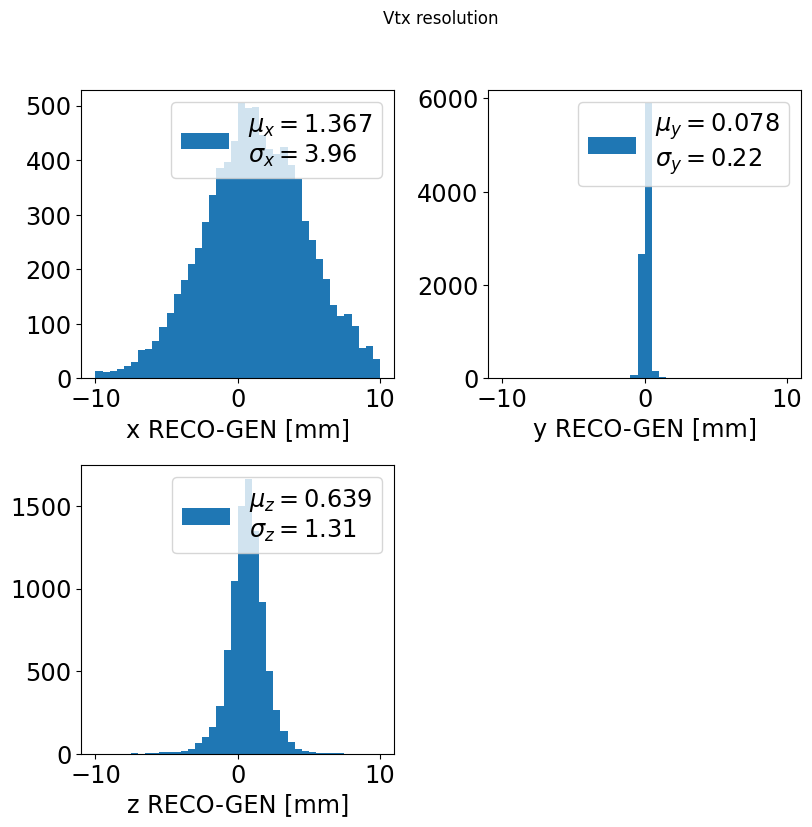

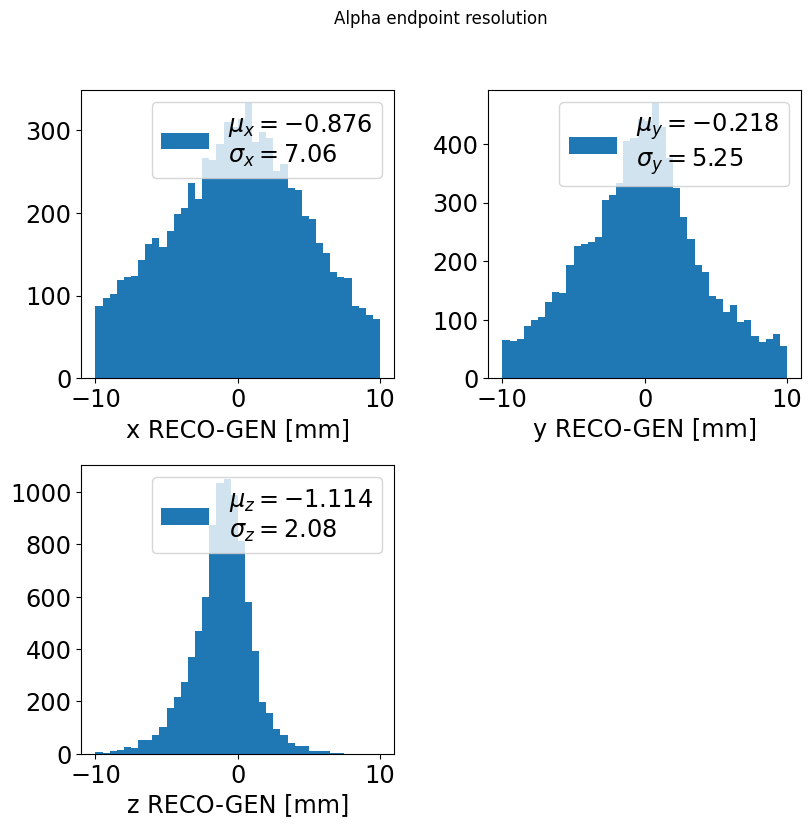

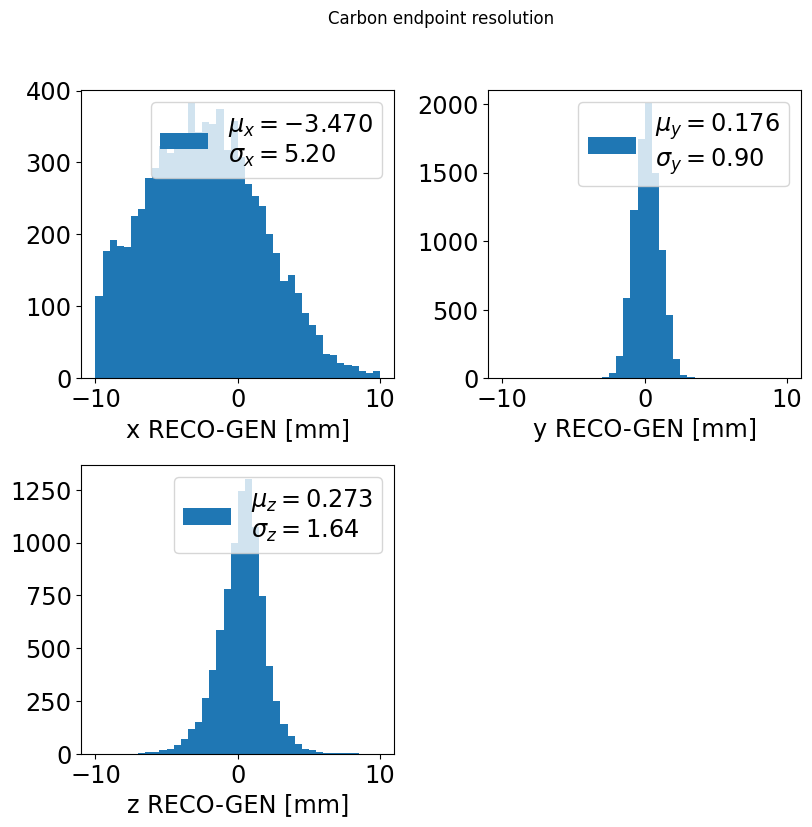

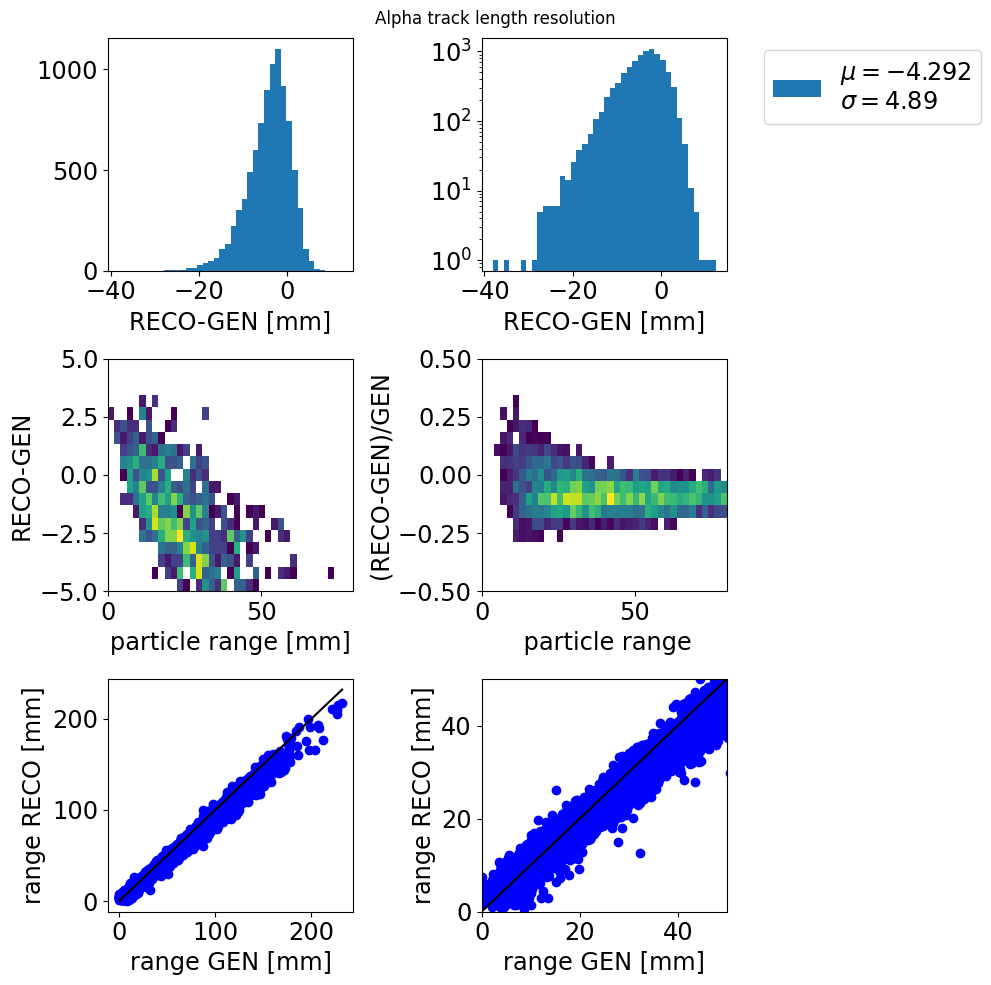

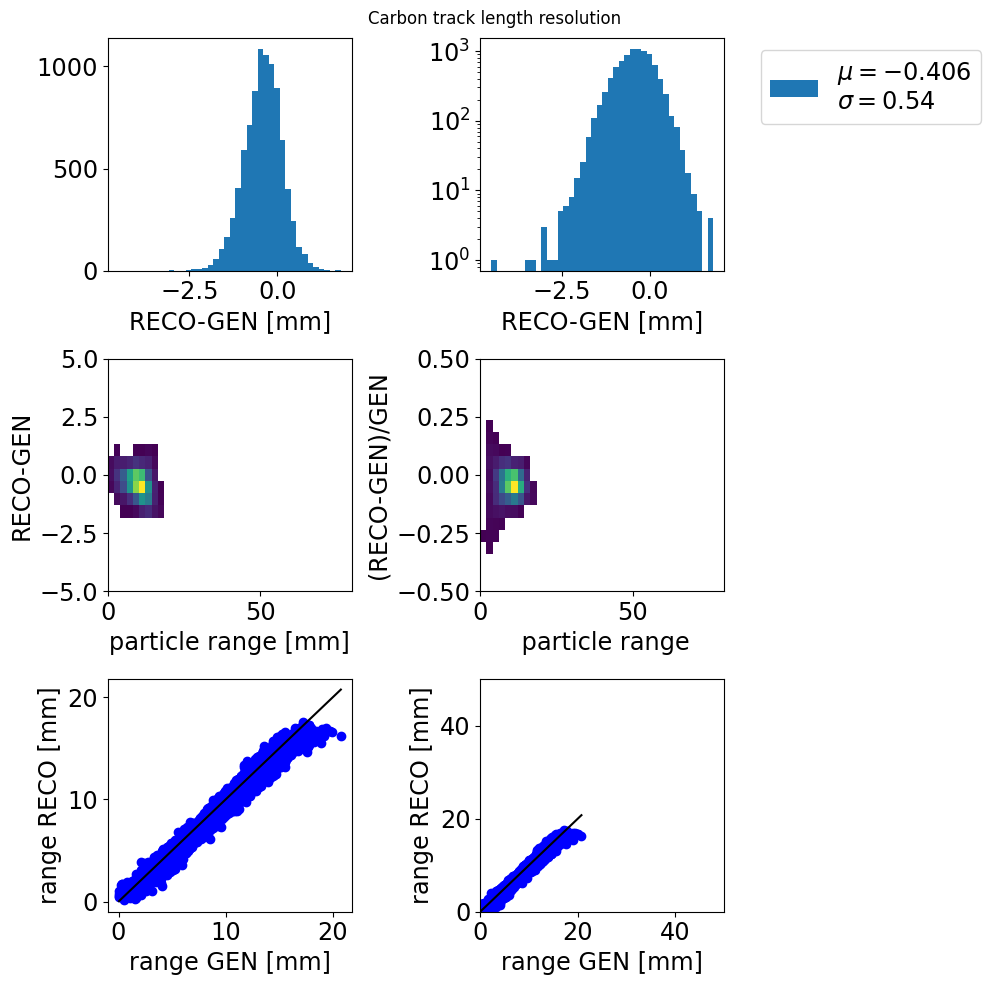

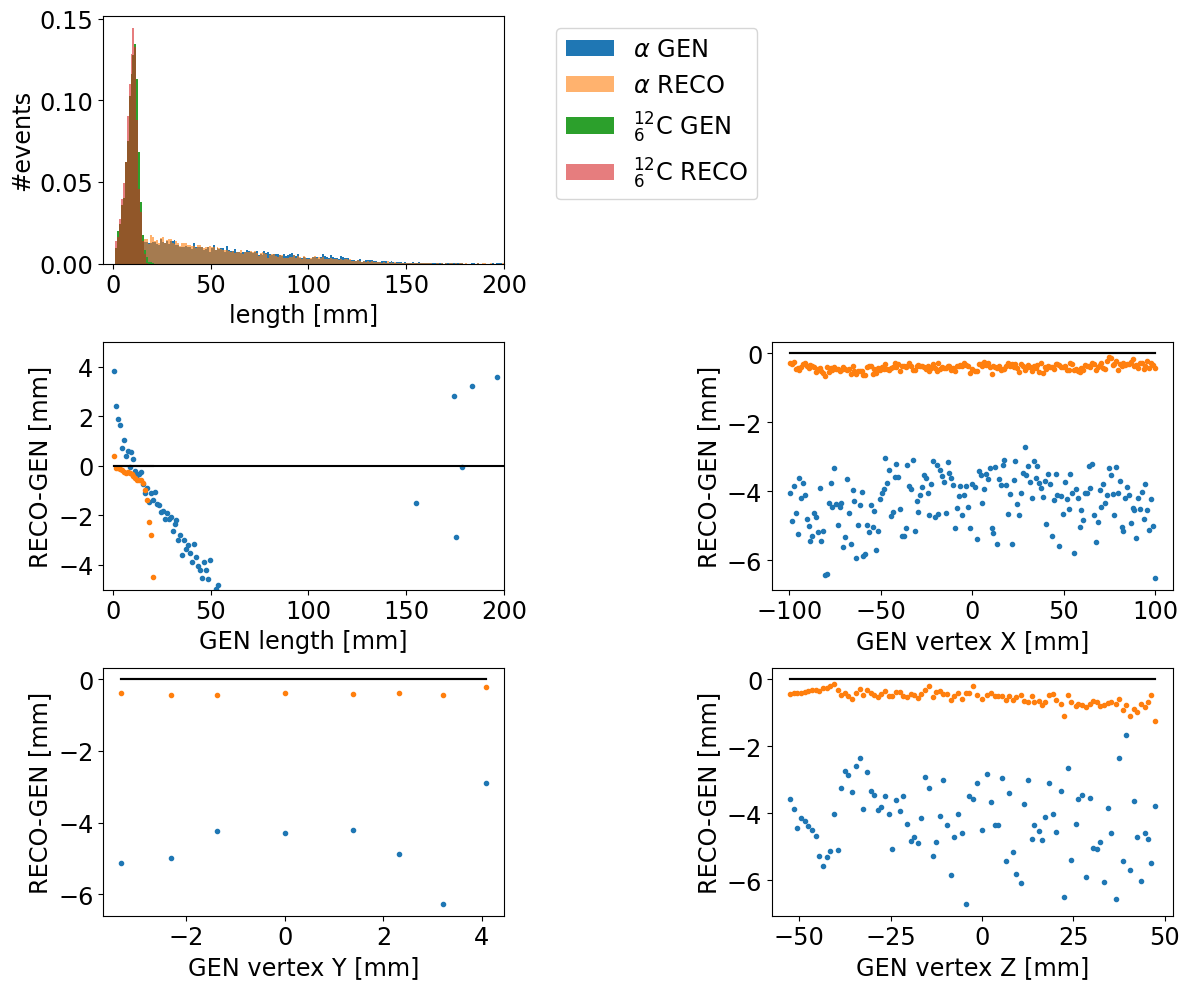

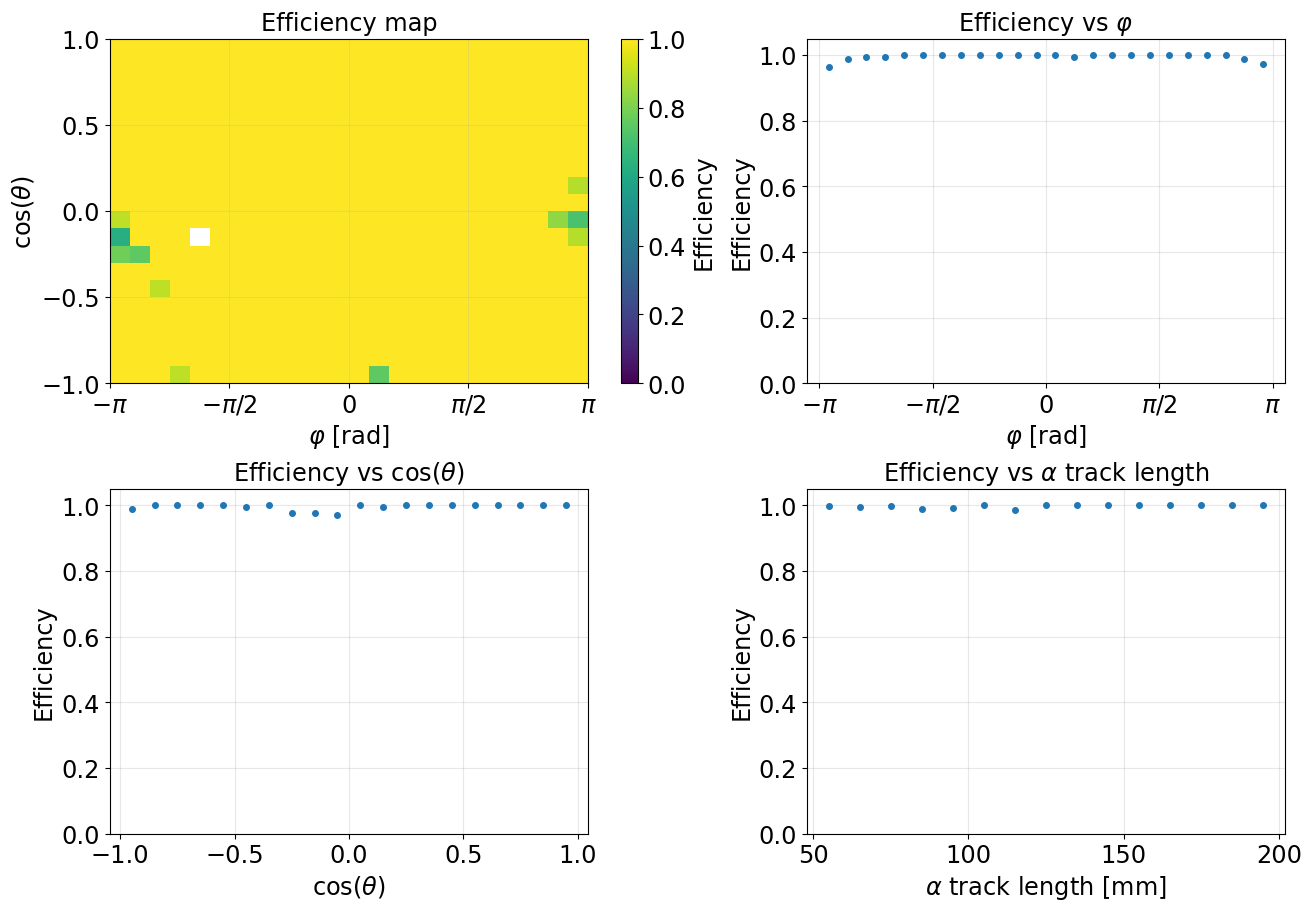

In [45]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df_XYZ, edge="Vtx",coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Alpha",coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Carbon",coordinates=["x", "y", "z"])

plf.plotLengthPull(df_XYZ, partName="Alpha")
plf.plotLengthPull(df_XYZ, partName="Carbon")
plf.plotLengthPullEvolution(df_XYZ)
# plf.plotOpeningAngleCos(df_XYZ)

numeratorSelection = (df_XYZ["pullAlpha"]/df_XYZ["dAlpha_sim"] < 0.05)
denominatorSelection = (
    (np.abs(df_XYZ["xAlpha_sim"]) < 140) &
    (np.abs(df_XYZ["yAlpha_sim"]) < 90) &
    (np.abs(df_XYZ["zAlpha_sim"]) < 60) &
    (df_XYZ['dAlpha_sim'] > 50)
)

plf.plotEffMaps(df_XYZ, numeratorSelection, denominatorSelection)
pass

In [26]:
v_true = np.stack([
    df_XYZ["xAlpha_sim"] - df_XYZ["xVtx_sim"],
    df_XYZ["yAlpha_sim"] - df_XYZ["yVtx_sim"],
    df_XYZ["zAlpha_sim"] - df_XYZ["zVtx_sim"]
], axis=1)

v_reco = np.stack([
    df_XYZ["xAlpha_reco"] - df_XYZ["xVtx_reco"],
    df_XYZ["yAlpha_reco"] - df_XYZ["yVtx_reco"],
    df_XYZ["zAlpha_reco"] - df_XYZ["zVtx_reco"]
], axis=1)

v_true_unit = v_true / np.linalg.norm(v_true, axis=1, keepdims=True)

vector_error_parallel = np.sum((v_reco - v_true) * v_true_unit, axis=1)

print(vector_error_parallel.mean(), vector_error_parallel.std())

-4.5652876 4.7131586
